In [1]:
# Importing libraries for the assigment 

import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loading datasets with pandas
students_dataset_part_2a = pd.read_csv("C:/Users/aldom/Msc Data Science/Modules/Module 3 - Programming for Data Science/Assessment/Assessment resources/part_2a.csv")
students_dataset_part_2b = pd.read_csv("C:/Users/aldom/Msc Data Science/Modules\Module 3 - Programming for Data Science/Assessment/Assessment resources/part_2b.csv")

#print the first 5 rows of the datasets
print("This is the first 5 rows of part 2a dataset:")
print(students_dataset_part_2a.head())

print("This is the first 5 rows of part 2b dataset:")
print(students_dataset_part_2b.head())

# describe the datasets with pandas to have an intial understanding of the data (such as spotting missing values particularly for this exercise)
print ("This is a descriptive statistics summary of part 2a :")
print(students_dataset_part_2a.describe().round(2))

print ("This is a descriptive statistics summary of part 2b datasets:")
print(students_dataset_part_2b.describe().round(2))

<>:11: SyntaxWarning: invalid escape sequence '\M'
<>:11: SyntaxWarning: invalid escape sequence '\M'
C:\Users\aldom\AppData\Local\Temp\ipykernel_9316\4267785688.py:11: SyntaxWarning: invalid escape sequence '\M'
  students_dataset_part_2b = pd.read_csv("C:/Users/aldom/Msc Data Science/Modules\Module 3 - Programming for Data Science/Assessment/Assessment resources/part_2b.csv")


This is the first 5 rows of part 2a dataset:
   Unnamed: 0  id_student gender                region      highest_education  \
0           0       11391      M   East Anglian Region       HE Qualification   
1           1       28400      F              Scotland       HE Qualification   
2           2       31604      F     South East Region  A Level or Equivalent   
3           3       32885      F  West Midlands Region     Lower Than A Level   
4           4       38053      M                 Wales  A Level or Equivalent   

  age_band disability final_result  score  
0     55<=          N         Pass   82.0  
1    35-55          N         Pass   67.0  
2    35-55          N         Pass   76.0  
3     0-35          N         Pass   55.0  
4    35-55          N         Pass   68.0  
This is the first 5 rows of part 2b dataset:
   id_student  click_events
0        6516        2791.0
1        8462         656.0
2       11391         934.0
3       23629           NaN
4       23698      

In [2]:
# Check for null values in students_dataset_part_2a
null_values_part_2a = students_dataset_part_2a.isnull().sum()
print("Null values in students_dataset_part_2a:")
print(null_values_part_2a)

# Check for null values in students_dataset_part_2b
null_values_part_2b = students_dataset_part_2b.isnull().sum()
print("\nNull values in students_dataset_part_2b:")
print(null_values_part_2b)

Null values in students_dataset_part_2a:
Unnamed: 0            0
id_student            0
gender                0
region                0
highest_education     0
age_band              0
disability            0
final_result          0
score                19
dtype: int64

Null values in students_dataset_part_2b:
id_student         0
click_events    1331
dtype: int64


In [3]:
# remove useless column 'Unnamed: 0' in part 2a dataset (this is a useless column that can cause merging issues later)
students_dataset_part_2a = students_dataset_part_2a.drop(columns=['Unnamed: 0'])

In [4]:
# Drop null values in students_dataset_part_2a
students_dataset_part_2a = students_dataset_part_2a.dropna()

# Drop null values in students_dataset_part_2b
students_dataset_part_2b = students_dataset_part_2b.dropna()

print("Null values have been dropped from both datasets.")

Null values have been dropped from both datasets.


In [5]:
# finding the number of rows in each dataset
print(len(students_dataset_part_2a))
print(len(students_dataset_part_2b))

# Check uniqueness (sinlge values or duplicates)
print(students_dataset_part_2a['id_student'].is_unique)
print(students_dataset_part_2b['id_student'].is_unique) 

print ("\nDataset part 2a has duplicate values in id_student column, while part 2b has single values")

26727
24743
False
True

Dataset part 2a has duplicate values in id_student column, while part 2b has single values


In [6]:
# Count duplicates in students_dataset_part_2a
duplicates_part_2a = students_dataset_part_2a.duplicated().sum()
print(f"Number of duplicate rows in students_dataset_part_2a: {duplicates_part_2a}")

# Count duplicates in students_dataset_part_2b
duplicates_part_2b = students_dataset_part_2b.duplicated().sum()
print(f"Number of duplicate rows in students_dataset_part_2b: {duplicates_part_2b}")

# Total duplicates across both datasets
total_duplicates = duplicates_part_2a + duplicates_part_2b
print(f"\nTotal number of duplicate rows across both datasets: {total_duplicates}")

Number of duplicate rows in students_dataset_part_2a: 1427
Number of duplicate rows in students_dataset_part_2b: 0

Total number of duplicate rows across both datasets: 1427


In [7]:
# Drop full duplicates from students_dataset_part_2a
students_dataset_part_2a = students_dataset_part_2a.drop_duplicates()

print("Duplicates have been removed from datasets.")

Duplicates have been removed from datasets.


In [8]:
# Verify if duplicates are removed in part 2a
duplicates_part_2a = students_dataset_part_2a.duplicated().sum()
print(f"Number of duplicate rows in students_dataset_part_2a: {duplicates_part_2a}")

Number of duplicate rows in students_dataset_part_2a: 0


In [9]:
# Perform a left join on id_student
merged_dataset = pd.merge(students_dataset_part_2a, students_dataset_part_2b, on='id_student', how='left')

# Display the first few rows of the merged dataset
print(merged_dataset.head())

   id_student gender                region      highest_education age_band  \
0       11391      M   East Anglian Region       HE Qualification     55<=   
1       28400      F              Scotland       HE Qualification    35-55   
2       31604      F     South East Region  A Level or Equivalent    35-55   
3       32885      F  West Midlands Region     Lower Than A Level     0-35   
4       38053      M                 Wales  A Level or Equivalent    35-55   

  disability final_result  score  click_events  
0          N         Pass   82.0         934.0  
1          N         Pass   67.0        1435.0  
2          N         Pass   76.0        2158.0  
3          N         Pass   55.0        1034.0  
4          N         Pass   68.0        2445.0  


In [10]:
# Descriptive analysis of the merged dataset
print("Descriptive statistics for numerical columns:")
print(merged_dataset.describe().round(2))

print("\nDescriptive statistics for categorical columns:") #skipping a row to improve readability
print(merged_dataset.describe(include=['object']))

Descriptive statistics for numerical columns:
       id_student     score  click_events
count    25300.00  25300.00      23984.00
mean    709382.59     73.37       1755.92
std     556598.05     15.48       2035.15
min       6516.00      0.00          1.00
25%     504366.75     65.00        451.00
50%     589011.50     76.00       1065.00
75%     642878.25     85.00       2339.00
max    2698588.00    100.00      28615.00

Descriptive statistics for categorical columns:
       gender    region      highest_education age_band disability  \
count   25300     25300                  25300    25300      25300   
unique      2        13                      5        3          2   
top         M  Scotland  A Level or Equivalent     0-35          N   
freq    13790      2746                  11261    17551      22918   

       final_result  
count         25300  
unique            4  
top            Pass  
freq          11890  


In [11]:
# I will be ranking education levels and group them to see perfromances across age

# Rank highest education based on their occurrence in the dataset
education_rank = merged_dataset['highest_education'].value_counts().rank()

# Map the rank back to the dataset
merged_dataset['education_rank'] = merged_dataset['highest_education'].map(education_rank)

# Group by highest education and calculate the mean score for each group
grouped_education = merged_dataset.groupby('highest_education')['score'].mean().round(2)

#show from hihest to lowest mean score
grouped_education = grouped_education.sort_values(ascending=False)

print("Ranked highest education and grouped mean scores:")
print(grouped_education)

Ranked highest education and grouped mean scores:
highest_education
Post Graduate Qualification    82.16
HE Qualification               75.75
A Level or Equivalent          74.09
Lower Than A Level             71.51
No Formal quals                66.49
Name: score, dtype: float64


In [12]:
# I am ranking the age group as well to bin them later to see performace differences

# Rank age_band based on their occurrence in the dataset
age_band_rank = merged_dataset['age_band'].value_counts().rank(ascending=False)

# Map the rank back to the dataset
merged_dataset['age_band_rank'] = merged_dataset['age_band'].map(age_band_rank)

# Group by age_band and calculate the mean score for each group
grouped_age_band = merged_dataset.groupby('age_band')['score'].mean().round(2)

print("Ranked age_band and grouped mean scores:")
print(grouped_age_band)

Ranked age_band and grouped mean scores:
age_band
0-35     72.61
35-55    75.02
55<=     77.27
Name: score, dtype: float64


In [13]:
# I will analyze the score distribution across the dataset to see how scores are distributed among students, a key action is to bin the scores into ranges for better insights

def analyze_score_distribution(merged_dataset, bin_size=5, min_score=0, max_score=100):

    bins = range(min_score, max_score + bin_size, bin_size)
    labels = [f"{i}-{i+bin_size-1}" for i in bins[:-1]] # list comprehension to create labels and faster compute analysis
    
    score_bins = pd.cut(merged_dataset['score'], 
                       bins=bins,
                       labels=labels,
                       right=False) #For this analysis of student scores, using right=False ensures that a score of 75 is counted in the "75-79" group rather than "70-74", which is typically more intuitive for educational scoring systems.
    
    distribution = merged_dataset.groupby(score_bins)['id_student'].agg(['count', 'nunique'])
    return distribution

# Print the first 10 results of the score distribution analysis
print(analyze_score_distribution(merged_dataset).head(10))

       count  nunique
score                
0-4      109      106
5-9       11       11
10-14     41       40
15-19     27       27
20-24     71       68
25-29    101       93
30-34    160      156
35-39    256      238
40-44    463      429
45-49    637      572


C:\Users\aldom\AppData\Local\Temp\ipykernel_9316\3155512063.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distribution = merged_dataset.groupby(score_bins)['id_student'].agg(['count', 'nunique'])


In [14]:
# Now I am counting for a descriptive purpose the number of students who scored less than 50 in the merged dataset to see how many students are underperforming

# Count the number of students who scored less than 50 in the merged dataset
less_than_50_count = merged_dataset[merged_dataset['score'] < 50].shape[0]
print(f"Number of students who scored less than 50 is: {less_than_50_count}")

# Count the number of fails in the merged dataset
fail_count_merged = merged_dataset[merged_dataset['final_result'] == 'Fail'].shape[0]
print(f"Number of student who fails is: {fail_count_merged}")

# Count the number of withdrawn in the merged dataset
withdrawn_count_merged = merged_dataset[merged_dataset['final_result'] == 'Withdrawn'].shape[0]
print(f"Number of students withdrawn is: {withdrawn_count_merged}")

print("\nPlease note that qualifications are different among groups therefore this insight gives a general overview of the dataset but not a specific one per group")

Number of students who scored less than 50 is: 1876
Number of student who fails is: 5654
Number of students withdrawn is: 4848

Please note that qualifications are different among groups therefore this insight gives a general overview of the dataset but not a specific one per group


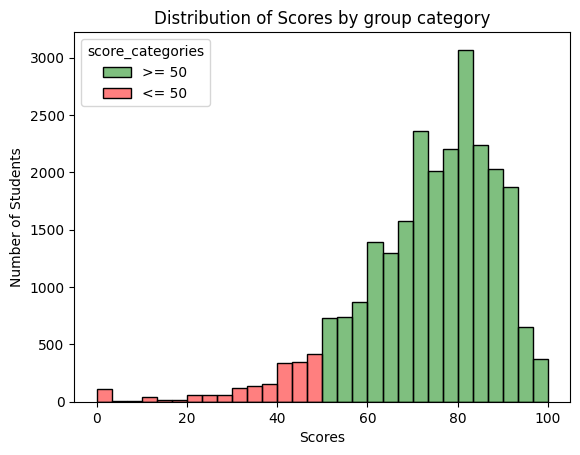

In [15]:
# Categorize students based on their scores
score_categories = merged_dataset['score'].apply(lambda x: '>= 50' if x >= 50 else '<= 50')

# Add the score_categories column to the dataframe
merged_dataset['score_categories'] = score_categories

# Visualize the counts using a histogram with different colors for each category
sns.histplot(data=merged_dataset, x='score', hue='score_categories', palette={'>= 50': 'green', '<= 50': 'red'}, bins=30, kde=False)
plt.title('Distribution of Scores by group category')
plt.xlabel('Scores')
plt.ylabel('Number of Students')
plt.show()


C:\Users\aldom\AppData\Local\Temp\ipykernel_9316\4189499459.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_dataset, x='age_band', order=['0-35', '35-55', '55<='], palette={'0-35': 'blue', '35-55': 'orange', '55<=': 'green'})


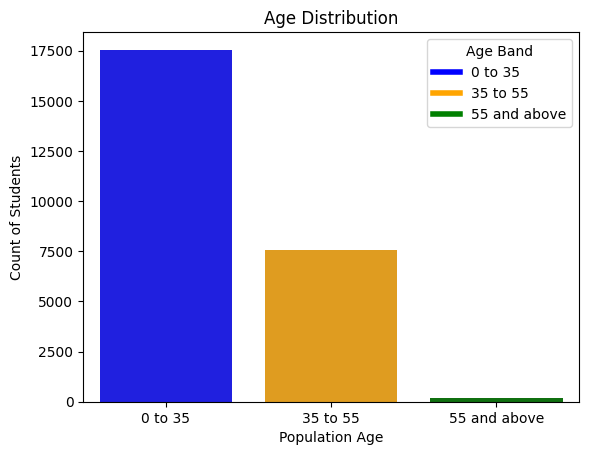

C:\Users\aldom\AppData\Local\Temp\ipykernel_9316\4189499459.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_dataset, x='age_band', y='score', order=['0-35', '35-55', '55<='], palette={'0-35': 'blue', '35-55': 'orange', '55<=': 'green'})


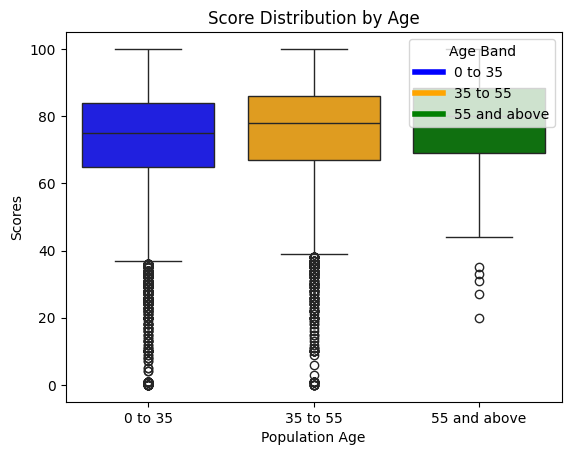

In [16]:
# Visualize age_band distribution with custom colors and legend
sns.countplot(data=merged_dataset, x='age_band', order=['0-35', '35-55', '55<='], palette={'0-35': 'blue', '35-55': 'orange', '55<=': 'green'})
plt.xticks(ticks=[0, 1, 2], labels=['0 to 35', '35 to 55', '55 and above'])
plt.title('Age Distribution')
plt.xlabel('Population Age')
plt.ylabel('Count of Students')
plt.legend(handles=[
    plt.Line2D([0], [0], color='blue', lw=4, label='0 to 35'),
    plt.Line2D([0], [0], color='orange', lw=4, label='35 to 55'),
    plt.Line2D([0], [0], color='green', lw=4, label='55 and above')
], title='Age Band', loc='upper right')
plt.show()

# Visualize score distribution by age_band with custom colors and legend
sns.boxplot(data=merged_dataset, x='age_band', y='score', order=['0-35', '35-55', '55<='], palette={'0-35': 'blue', '35-55': 'orange', '55<=': 'green'})
plt.xticks(ticks=[0, 1, 2], labels=['0 to 35', '35 to 55', '55 and above'])
plt.xlabel('Population Age')
plt.ylabel('Scores')
plt.title('Score Distribution by Age')
plt.legend(handles=[
    plt.Line2D([0], [0], color='blue', lw=4, label='0 to 35'),
    plt.Line2D([0], [0], color='orange', lw=4, label='35 to 55'),
    plt.Line2D([0], [0], color='green', lw=4, label='55 and above')
], title='Age Band', loc='upper right')
plt.show()

C:\Users\aldom\AppData\Local\Temp\ipykernel_9316\2804199448.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  score_pivot = merged_dataset.pivot_table(index='score_bins', values='id_student', aggfunc='count')


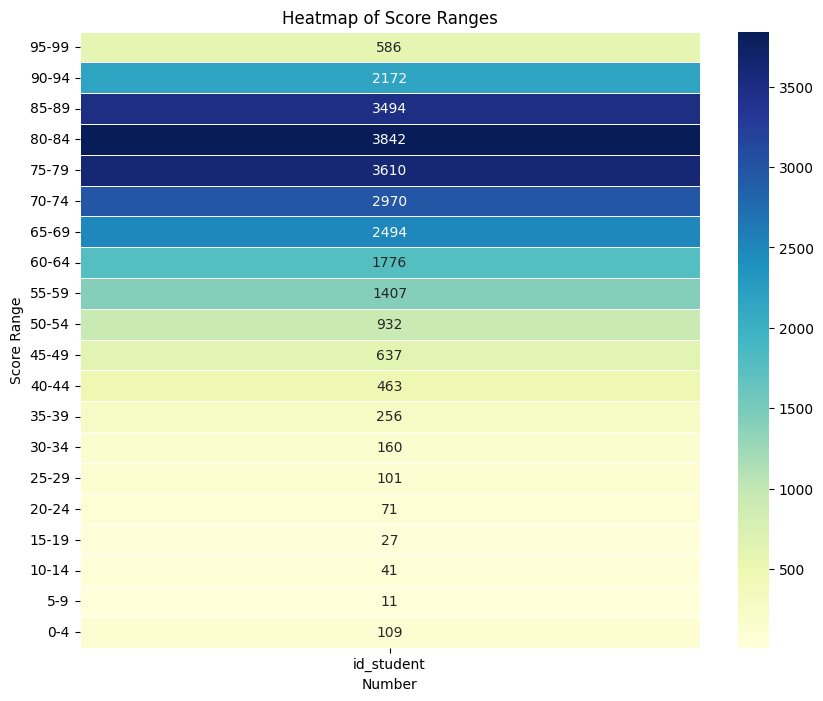

In [17]:
# Define score bins
bins = range(0, 105, 5)  # Bins from 0 to 100 with a step of 5
labels = [f"{i}-{i+4}" for i in bins[:-1]]  # Labels for the bins # that is exactly a list comprehension.

# Add the score_bins column to the dataframe
merged_dataset['score_bins'] = pd.cut(merged_dataset['score'], bins=bins, labels=labels, right=False)

# Create a pivot table for the score distribution
score_pivot = merged_dataset.pivot_table(index='score_bins', values='id_student', aggfunc='count')

# Invert the rank in the central plot
score_pivot = score_pivot.iloc[::-1]

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(score_pivot, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Heatmap of Score Ranges')
plt.xlabel('Number')
plt.ylabel('Score Range')
plt.show()

In [18]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = merged_dataset['score'].quantile(0.25)
Q3 = merged_dataset['score'].quantile(0.75)

# Calculate the IQR
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count the number of outliers
outliers = merged_dataset[(merged_dataset['score'] < lower_bound) | (merged_dataset['score'] > upper_bound)]
outlier_count = outliers.shape[0]

print(f"Number of outliers in the score column: {outlier_count}")

Number of outliers in the score column: 520


C:\Users\aldom\AppData\Local\Temp\ipykernel_9316\2211779435.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_dataset, x='score', y='age_band', palette=age_group_colors)


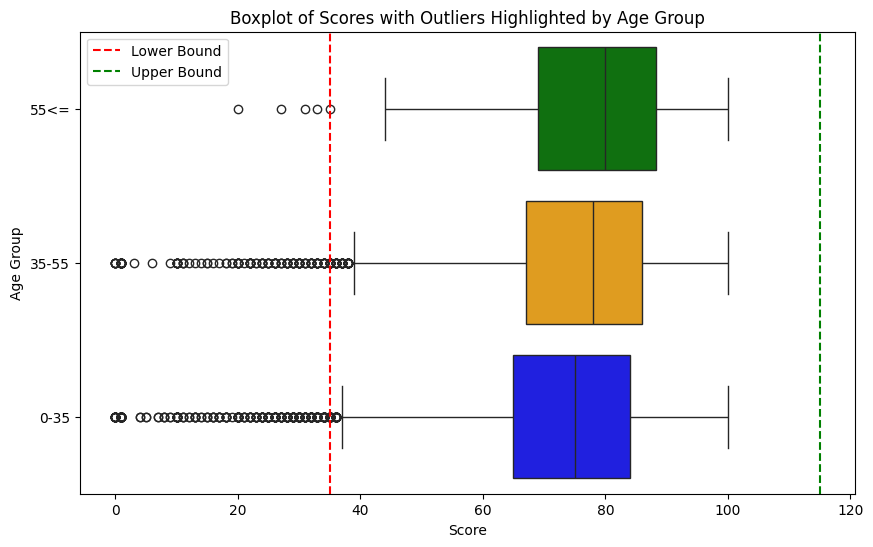

In [19]:
# Visualizing the outliers by age groups with theme colour as previous boxplots
age_group_colors = {'0-35': 'blue', '35-55': 'orange', '55<=': 'green'}


plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_dataset, x='score', y='age_band', palette=age_group_colors)
plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')
plt.title('Boxplot of Scores with Outliers Highlighted by Age Group')
plt.xlabel('Score')
plt.ylabel('Age Group')
plt.legend()
plt.show()

In [20]:
print("Outliers will be kept in the dataset for the following reasons:")

print("\n1. Outliers represent higher and lower scoring results among students rather than errors.")

print("2. Removing outliers will lead to a loss of key information, especially in this educational datasets where it is important to determinate each group's performance.")

print("3. Outliers will provide insights into specific groups of students who may require additional support or resources.")

Outliers will be kept in the dataset for the following reasons:

1. Outliers represent higher and lower scoring results among students rather than errors.
2. Removing outliers will lead to a loss of key information, especially in this educational datasets where it is important to determinate each group's performance.
3. Outliers will provide insights into specific groups of students who may require additional support or resources.


Anderson-Darling test statistic: 361.01065121541615
Critical values: [0.576 0.656 0.787 0.918 1.092]
Significance levels: [15.  10.   5.   2.5  1. ]
The distribution of scores is not normal (at 5% significance level).


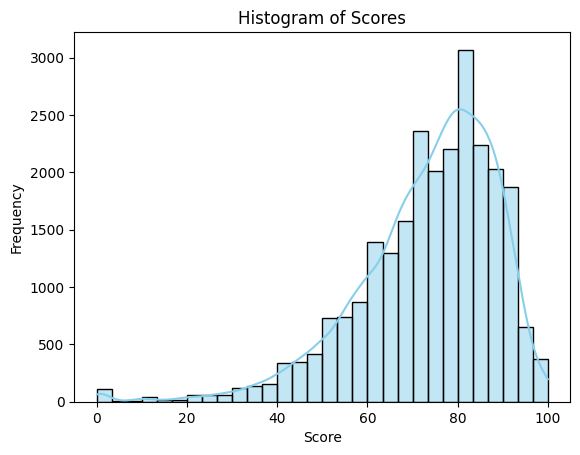

In [21]:
from scipy.stats import anderson, probplot

# Perform the Anderson-Darling test for normality
result = anderson(merged_dataset['score'])
print("Anderson-Darling test statistic:", result.statistic)
print("Critical values:", result.critical_values)
print("Significance levels:", result.significance_level)

# Interpret the result
if result.statistic > result.critical_values[2]:  # Compare with 5% significance level
    print("The distribution of scores is not normal (at 5% significance level).")
else:
    print("The distribution of scores is normal (at 5% significance level).")

# Visualize the distribution
sns.histplot(merged_dataset['score'], kde=True, color='skyblue', bins=30)
plt.title('Histogram of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()


In [22]:
from scipy.stats import kruskal  # is like anova but non-parametric

# Remove rows with NaN values in the 'score' column
cleaned_dataset = merged_dataset.dropna(subset=['score'])

# Extract scores for each age_band group
scores_0_35 = cleaned_dataset[cleaned_dataset['age_band'] == '0-35']['score']
scores_35_55 = cleaned_dataset[cleaned_dataset['age_band'] == '35-55']['score']
scores_55_plus = cleaned_dataset[cleaned_dataset['age_band'] == '55<=']['score']

# Perform the Kruskal-Wallis H Test
h_stat, p_value = kruskal(scores_0_35, scores_35_55, scores_55_plus)

# Print the results
print("Kruskal-Wallis H Test statistic:", h_stat)
print("P-value:", p_value)

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: At least one age group has a different score distribution.")
else:
    print("Fail to reject the null hypothesis: All age groups have the same score distribution.")

Kruskal-Wallis H Test statistic: 196.2637805468678
P-value: 2.409137320954432e-43
Reject the null hypothesis: At least one age group has a different score distribution.


In [23]:
# Here I am defining the null and alternative hypotheses

print("Hypothesis Test:")
print("H0 (Null Hypothesis): Different age groups have the same score distribution.")
print("H1 (Alternative Hypothesis): At least one age group has a different score distribution.")

# Significance level
print("\nSignificance Level (α):", alpha)

# Display the test statistic and p-value from the Kruskal-Wallis H Test
print("\nTest Statistic (H):", h_stat)
print("P-value:", p_value) # this is a very small number 0.00 at 2 decimals

# Result
if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis (H0).")
    print("There is sufficient evidence to conclude that at least one age group has a different score distribution.")
else:
    print("\nConclusion: Fail to reject the null hypothesis (H0).")
    print("There is insufficient evidence to conclude that different age groups have different score distributions.")

Hypothesis Test:
H0 (Null Hypothesis): Different age groups have the same score distribution.
H1 (Alternative Hypothesis): At least one age group has a different score distribution.

Significance Level (α): 0.05

Test Statistic (H): 196.2637805468678
P-value: 2.409137320954432e-43

Conclusion: Reject the null hypothesis (H0).
There is sufficient evidence to conclude that at least one age group has a different score distribution.
